---
---
---

# Model

---
---
---

<br>

> | **_Language:_** python@3.12.10 |
> | - |

<br>

> | **_Source:_** `notebook/analysis_reg.ipynb` |
> | - |

<br>

> | **_Configurations:_** `lib/config` |
> | - |

<br>

> | **_Libraries:_** `lib/utils` |
> | - |

<br>

---
---
---

## Dependencies

### Packages

In [1]:
from google.cloud import bigquery
from loguru import logger
from matplotlib import pyplot as plt
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import joblib
import json
import numpy as np
import pandas as pd
import sys
import warnings

ROOT_PATH = Path.cwd().resolve()
if ROOT_PATH.name == "notebook":
    ROOT_PATH = ROOT_PATH.parent
if str(ROOT_PATH) not in sys.path:
    sys.path.insert(0, str(ROOT_PATH))

from lib import config as the_config
from lib import utils as the_utils
from lib import ml_metrics as metrics_lib
from lib.automl import AutoMLClassifier, AutoMLRegressor

# -------------------------

# Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.float_format", "{:.3f}".format)
warnings.filterwarnings("ignore")

### Constants

In [2]:
# GCP
BQ_CLIENT = bigquery.Client(project=the_config.GCP_PROJECT)

### Paths

In [3]:
for path in the_config.PATHS:
    the_utils.ensure_path(path)

## DataFrame

In [4]:
# [!]
query = f"""
SELECT * FROM `{the_config.BQ_TABLE}`
ORDER BY TIMESTAMP(
    DATETIME(year, month, day, hour, minute, 0)
)
"""
df = BQ_CLIENT.query(query).to_dataframe()
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114798 entries, 0 to 114797
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   date                 114798 non-null  dbdate 
 1   year                 114798 non-null  Int64  
 2   month                114798 non-null  Int64  
 3   day                  114798 non-null  Int64  
 4   hour                 114798 non-null  Int64  
 5   minute               114798 non-null  Int64  
 6   quarter              114798 non-null  Int64  
 7   week_of_year         114798 non-null  Int64  
 8   day_of_year          114798 non-null  Int64  
 9   day_of_week          114798 non-null  Int64  
 10  station              114798 non-null  object 
 11  city                 114798 non-null  object 
 12  province             114798 non-null  object 
 13  latitude             114798 non-null  float64
 14  longitude            114798 non-null  float64
 15  temperature_c    

None

## Feature Engineering

In [5]:
# [!]
# Feature Engineering -- Classification
clf_df = df.iloc[-the_config.HYPER_SPACE["sampling"]:]
clf_df, target_clf = the_utils.feature_engineering_clf(clf_df)
logger.debug(f"[LIST] Targets ({len(target_clf)}): {target_clf}")

2026-08-18 23:27:52.038 | DEBUG    | __main__:<module>:4 - [LIST] Targets (1): ['rain_flag']


In [6]:
# [!]
# Feature Engineering -- Regression
reg_df = df.iloc[-the_config.HYPER_SPACE["sampling"]:]
reg_df, targets_reg = the_utils.feature_engineering_reg(reg_df)
logger.debug(f"[LIST] Targets ({len(targets_reg)}): {targets_reg}")

2026-08-18 23:27:52.869 | DEBUG    | __main__:<module>:4 - [LIST] Targets (24): ['temperature_c_lead_30', 'humidity_pct_lead_30', 'dew_point_c_lead_30', 'pressure_hpa_lead_30', 'wind_x_lead_30', 'wind_y_lead_30', 'temperature_c_lead_60', 'humidity_pct_lead_60', 'dew_point_c_lead_60', 'pressure_hpa_lead_60', 'wind_x_lead_60', 'wind_y_lead_60', 'temperature_c_lead_90', 'humidity_pct_lead_90', 'dew_point_c_lead_90', 'pressure_hpa_lead_90', 'wind_x_lead_90', 'wind_y_lead_90', 'temperature_c_lead_120', 'humidity_pct_lead_120', 'dew_point_c_lead_120', 'pressure_hpa_lead_120', 'wind_x_lead_120', 'wind_y_lead_120']


## Training

### Train-Test Split

In [7]:
# [!]
# Feature Selection -- Classification
to_drop = [
    "date", "year", "month", "day", "hour", "minute",
    "quarter", "week_of_year", "day_of_year", "day_of_week",
    "province", "city", "station",
    "wind_speed_kmh", "wind_dir",
    "rain_mm", "rain_mmh",
    the_config.CLASSIFICATION["targets"][0]
]
to_drop += [c for c in clf_df.columns if c.lower().startswith("conf_")]
X_clf = clf_df.drop(columns=to_drop)
y_clf = clf_df[the_config.CLASSIFICATION["targets"][0]]

# [!]
# Train-Test Split -- Classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
	X_clf, y_clf,
    test_size=the_config.CLASSIFICATION["test_size"],
    shuffle=the_config.CLASSIFICATION["shuffle"],
    random_state=the_config.CLASSIFICATION["seed"]
)

logger.debug(f"{'[LIST]':<8}{'[CLF]':<6}{'Features:':<10}{X_train_clf.columns.tolist()}")
logger.debug(f"{'[LIST]':<8}{'[CLF]':<6}{'Labels:':<10}{y_train_clf.name}")
logger.debug(f"{'[TRAIN]':<8}{'[CLF]':<6}{'Shape:':<10}{y_train_clf.shape}")
logger.debug(f"{'[TEST]':<8}{'[CLF]':<6}{'Shape:':<10}{y_test_clf.shape}")

2026-08-18 23:27:52.914 | DEBUG    | __main__:<module>:24 - [LIST]  [CLF] Features: ['latitude', 'longitude', 'temperature_c', 'humidity_pct', 'dew_point_c', 'pressure_hpa']
2026-08-18 23:27:52.914 | DEBUG    | __main__:<module>:25 - [LIST]  [CLF] Labels:   rain_flag
2026-08-18 23:27:52.915 | DEBUG    | __main__:<module>:26 - [TRAIN] [CLF] Shape:    (91838,)
2026-08-18 23:27:52.915 | DEBUG    | __main__:<module>:27 - [TEST]  [CLF] Shape:    (22960,)


In [8]:
# [!]
# Feature Selection -- Regression
to_drop = [
    "date",
    "province", "city", "station",
    "wind_speed_kmh", "wind_dir",
    "rain_mm", "rain_mmh",
    *targets_reg
]
to_drop += [c for c in reg_df.columns if c.lower().startswith("conf_")]
X_reg = reg_df.drop(columns=to_drop)
y_reg = reg_df[targets_reg]

# [!]
# Train-Test Split -- Regression
X_train_reg = X_reg.iloc[:-the_config.INF_ROWS]
y_train_reg = y_reg.iloc[:-the_config.INF_ROWS]
X_test_reg = X_reg.iloc[-the_config.INF_ROWS:]
y_test_reg = y_reg.iloc[-the_config.INF_ROWS:]

logger.debug(f"{'[LIST]':<8}{'[REG]':<6}{'Features:':<10}{X_train_reg.columns.tolist()}")
logger.debug(f"{'[LIST]':<8}{'[REG]':<6}{'Labels:':<10}{y_train_reg.columns.tolist()}")
logger.debug(f"{'[TRAIN]':<8}{'[REG]':<6}{'Shape:':<10}{y_train_reg.shape}")
logger.debug(f"{'[TEST]':<8}{'[REG]':<6}{'Shape:':<10}{y_test_reg.shape}")

2026-08-18 23:27:53.046 | DEBUG    | __main__:<module>:21 - [LIST]  [REG] Features: ['year', 'month', 'day', 'hour', 'minute', 'quarter', 'week_of_year', 'day_of_year', 'day_of_week', 'latitude', 'longitude', 'temperature_c', 'humidity_pct', 'dew_point_c', 'pressure_hpa', 'wind_x', 'wind_y', 'temperature_c_lag_1', 'temperature_c_lag_2', 'temperature_c_lag_3', 'temperature_c_lag_6', 'temperature_c_lag_12', 'temperature_c_lag_18', 'temperature_c_lag_24', 'humidity_pct_lag_1', 'humidity_pct_lag_2', 'humidity_pct_lag_3', 'humidity_pct_lag_6', 'humidity_pct_lag_12', 'humidity_pct_lag_18', 'humidity_pct_lag_24', 'dew_point_c_lag_1', 'dew_point_c_lag_2', 'dew_point_c_lag_3', 'dew_point_c_lag_6', 'dew_point_c_lag_12', 'dew_point_c_lag_18', 'dew_point_c_lag_24', 'pressure_hpa_lag_1', 'pressure_hpa_lag_2', 'pressure_hpa_lag_3', 'pressure_hpa_lag_6', 'pressure_hpa_lag_12', 'pressure_hpa_lag_18', 'pressure_hpa_lag_24', 'wind_x_lag_1', 'wind_x_lag_2', 'wind_x_lag_3', 'wind_x_lag_6', 'wind_x_lag_12'

### Models

In [9]:
# AutoML Classifier -- LGBM
model_path = the_config.MODELS_NB_PATH / "lgbm_classifier.joblib"
if model_path.exists():
    lgbm_clf = joblib.load(model_path)

else:
	lgbm_clf = AutoMLClassifier(
		**the_config.HYPER_SPACE["automl_clf"],
		estimator_list=["lgbm"],
		seed=the_config.CLASSIFICATION["seed"]
	)
	lgbm_clf.fit(X_train_clf, y_train_clf)
display(lgbm_clf)

# [!]
# lgbm_clf = AutoMLClassifier(
# 	**the_config.HYPER_SPACE["automl_clf"],
# 	estimator_list=["lgbm"],
# 	seed=the_config.CLASSIFICATION["seed"]
# )
# lgbm_clf.fit(X_train_clf, y_train_clf)
# display(lgbm_clf)

# AutoML Regressor -- LGBM
model_path = the_config.MODELS_NB_PATH / "lgbm_regressor.joblib"
if model_path.exists():
    lgbm_reg = joblib.load(model_path)

else:
	lgbm_reg = AutoMLRegressor(
		**the_config.HYPER_SPACE["automl_reg"],
		estimator_list=["lgbm"],
		seed=the_config.REGRESSION["seed"]
	)
	lgbm_reg.fit(X_train_reg, y_train_reg)
display(lgbm_reg)

# [!]
# lgbm_reg = AutoMLRegressor(
# 	**the_config.HYPER_SPACE["automl_reg"],
# 	estimator_list=["lgbm"],
# 	seed=the_config.REGRESSION["seed"]
# )
# lgbm_reg.fit(X_train_reg, y_train_reg)
# display(lgbm_reg)

## Evaluation

In [10]:
# [!]
# Evaluation -- Classification
models_clf = {
    "LGBM Classifier": { "model": lgbm_clf, "metrics": {} }
}
for model_name, model_info in models_clf.items():

	logger.debug(f"Model: {model_name}")
	model = model_info["model"]
	model_metrics = model_info["metrics"]

	y_true_train_clf = y_train_clf
	y_true_test_clf = y_test_clf
	y_pred_train_clf = model.predict(X_train_clf)
	y_pred_test_clf = model.predict(X_test_clf)

	model_metrics[the_config.CLASSIFICATION["targets"][0]] = {}
	metrics_lib.compute_metrics_clf(
		model_metrics[the_config.CLASSIFICATION["targets"][0]],
		y_true_train_clf,
		y_pred_train_clf,
		model_classes=[0, 1],
		set="TRAIN"
	)
	metrics_lib.compute_metrics_clf(
		model_metrics[the_config.CLASSIFICATION["targets"][0]],
		y_true_test_clf,
		y_pred_test_clf,
		model_classes=[0, 1],
		set="TEST"
	)

2026-08-18 23:27:53.355 | DEBUG    | __main__:<module>:8 - Model: LGBM Classifier


In [11]:
# [!]
# Evaluation -- Regression
models_reg = {
    "LGBM Regressor": { "model": lgbm_reg, "metrics": {} }
}
for model_name, model_info in models_reg.items():

	logger.debug(f"Model: {model_name}")
	model = model_info["model"]
	model_metrics = model_info["metrics"]

	y_true_train_reg = y_train_reg
	y_true_test_reg = y_test_reg
	y_pred_train_reg = pd.DataFrame(
		model.predict(X_train_reg),
		columns=y_train_reg.columns,
		index=y_train_reg.index
	)
	y_pred_test_reg = pd.DataFrame(
		model.predict(X_test_reg),
		columns=y_test_reg.columns,
		index=y_test_reg.index
	)

	for forecast in the_config.FORECASTS:

		model_metrics[forecast] = {}
		for feature in the_config.REGRESSION["targets"]:

			col = f"{feature}_lead_{forecast}"
			model_metrics[forecast][feature] = {}
			metrics_lib.compute_metrics_reg(
				model_metrics[forecast][feature],
				y_true_train_reg[[col]],
				y_pred_train_reg[[col]],
				set="TRAIN"
			)
			metrics_lib.compute_metrics_reg(
				model_metrics[forecast][feature],
				y_true_test_reg[[col]],
				y_pred_test_reg[[col]],
				set="TEST"
			)

2026-08-18 23:27:53.690 | DEBUG    | __main__:<module>:8 - Model: LGBM Regressor


## Results

count   91838.000
mean        0.111
std         0.314
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         1.000
Name: rain_flag, dtype: float64

,Model,Target,Set,Size,Accuracy,Precision,Recall,F1 Score,Confusion Matrix
0,LGBM Classifier,rain_flag,TRAIN,91838,0.997,0.988,0.984,0.986,"[[81510, 120], [168, 10040]]"
1,LGBM Classifier,rain_flag,TEST,22960,0.997,0.990,0.981,0.986,"[[20452, 24], [46, 2438]]"


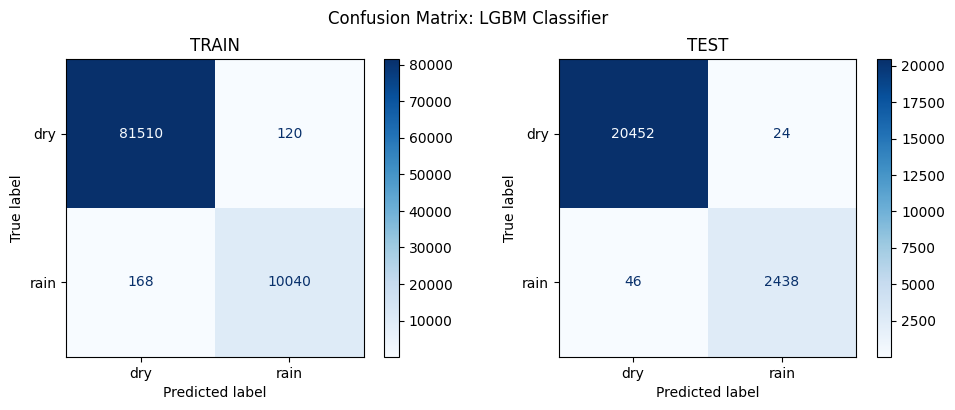

In [12]:
# [!]
# Metrics -- Classification
rows_clf = []
for model_name, model_info in models_clf.items():

	for target, sets in model_info["metrics"].items():
		for split in ["TRAIN", "TEST"]:

			size, accuracy, precision, recall, f1_score, cm = sets[split]
			rows_clf.append({
				"Model": model_name,
				"Target": target,
				"Set": split,
				"Size": size,
				"Accuracy": accuracy,
				"Precision": precision,
				"Recall": recall,
				"F1 Score": f1_score,
				"Confusion Matrix": cm
			})
metrics_clf_df = (
    pd.DataFrame(rows_clf)
    .reset_index(drop=True)
)

display(y_train_clf.describe())
display(metrics_clf_df)

# [!]
# Confusion Matrix -- Classification
for model_name in metrics_clf_df["Model"].unique():

    model_results = metrics_clf_df[
        metrics_clf_df["Model"] == model_name
    ]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ax, (_, row) in zip(
        axes,
        (
			model_results
			.set_index("Set")
			.loc[["TRAIN", "TEST"]]
			.reset_index()
			.iterrows()
		)
    ):

        cm = np.array(row["Confusion Matrix"])
        cm = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["dry", "rain"]
        )
        cm.plot(
            ax=ax,
            cmap="Blues",
            values_format="d"
        )
        ax.set_title(row["Set"])

    fig.suptitle(f"Confusion Matrix: {model_name}")
    fig.tight_layout()
    fig.savefig(
        the_config.MODELS_NB_PATH /
        f"{model_name.lower().replace(' ', '_')}_cm.png",
        bbox_inches="tight",
        dpi=300
    )
    plt.show()
    plt.close(fig)

In [13]:
# [!]
# Metrics -- Regression
rows_reg = []
for model_name, model_info in models_reg.items():
    for lead, targets in model_info["metrics"].items():
        for target, sets in targets.items():
            for split in ["TRAIN", "TEST"]:

                size, mae, rmse, r2 = sets[split]
                rows_reg.append({
                    "Model": model_name,
                    "Target": target,
                    "Lead": lead,
                    "Set": split,
                    "Size": size,
                    "MAE": mae,
                    "RMSE": rmse,
                    "R2": r2,
                })                
metrics_reg_df = (
    pd.DataFrame(rows_reg)
    .sort_values(["Target", "Lead"])
    .reset_index(drop=True)
)

display(y_train_reg.describe())
display(metrics_reg_df)

,temperature_c_lead_30,humidity_pct_lead_30,dew_point_c_lead_30,pressure_hpa_lead_30,wind_x_lead_30,wind_y_lead_30,temperature_c_lead_60,humidity_pct_lead_60,dew_point_c_lead_60,pressure_hpa_lead_60,wind_x_lead_60,wind_y_lead_60,temperature_c_lead_90,humidity_pct_lead_90,dew_point_c_lead_90,pressure_hpa_lead_90,wind_x_lead_90,wind_y_lead_90,temperature_c_lead_120,humidity_pct_lead_120,dew_point_c_lead_120,pressure_hpa_lead_120,wind_x_lead_120,wind_y_lead_120
count,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000,112350.000
mean,27.587,59.477,18.550,1014.406,0.022,0.255,27.584,59.472,18.545,1014.397,0.026,0.254,27.581,59.469,18.540,1014.389,0.030,0.255,27.577,59.469,18.536,1014.381,0.033,0.256
std,4.035,12.851,1.853,5.946,5.811,4.717,4.040,12.864,1.856,5.945,5.814,4.719,4.045,12.877,1.858,5.945,5.815,4.720,4.050,12.890,1.861,5.944,5.817,4.722
min,15.200,22.000,8.900,0.000,-35.400,-46.102,15.000,22.000,8.900,0.000,-35.400,-46.102,15.000,22.000,8.900,0.000,-35.400,-46.102,15.000,22.000,8.900,0.000,-35.400,-46.102
25%,24.800,50.000,17.400,1012.500,-1.225,-0.612,24.800,50.000,17.400,1012.500,-1.225,-0.612,24.800,50.000,17.400,1012.500,-1.225,-0.612,24.800,50.000,17.400,1012.500,-1.225,-0.612
50%,27.200,59.000,18.700,1014.400,-0.000,0.000,27.200,59.000,18.700,1014.400,0.000,0.000,27.200,59.000,18.700,1014.400,0.000,-0.000,27.200,59.000,18.700,1014.300,-0.000,0.000
75%,30.500,69.000,19.700,1016.300,1.225,1.131,30.500,69.000,19.700,1016.200,1.225,1.131,30.500,69.000,19.700,1016.200,1.225,1.131,30.500,69.000,19.700,1016.200,1.225,1.131
max,37.400,96.000,25.600,1022.400,64.400,54.700,37.400,96.000,25.600,1022.400,64.400,54.700,37.400,96.000,25.600,1022.400,64.400,54.700,37.400,96.000,25.600,1022.400,64.400,54.700


,Model,Target,Lead,Set,Size,MAE,RMSE,R2
0,LGBM Regressor,dew_point_c,30,TRAIN,112350,0.161,0.223,0.985
1,LGBM Regressor,dew_point_c,30,TEST,456,0.632,0.863,0.467
2,LGBM Regressor,dew_point_c,60,TRAIN,112350,0.172,0.235,0.984
3,LGBM Regressor,dew_point_c,60,TEST,456,0.751,1.022,0.257
4,LGBM Regressor,dew_point_c,90,TRAIN,112350,0.360,0.486,0.931
5,LGBM Regressor,dew_point_c,90,TEST,456,0.779,1.043,0.226
6,LGBM Regressor,dew_point_c,120,TRAIN,112350,0.226,0.306,0.973
7,LGBM Regressor,dew_point_c,120,TEST,456,0.826,1.097,0.144
8,LGBM Regressor,humidity_pct,30,TRAIN,112350,1.038,1.486,0.987
9,LGBM Regressor,humidity_pct,30,TEST,456,2.607,4.536,0.860


In [14]:
# [!]
# Metrics -- Models
for models_task in [models_clf, models_reg]:
	for model_name, model_info in models_task.items():

		model = model_info["model"]
		filename = model_name.lower().replace(" ", "_")
		joblib.dump(
			model,
			the_config.MODELS_NB_PATH / f"{filename}.joblib"
		)

# [!]
# Metrics -- Classification
with open(the_config.MODELS_NB_PATH / "stats_clf.json", "w") as f:
    json.dump(
        (
			y_train_clf.to_frame().describe().T
			.to_dict(orient="index")
		),
        f, indent=4
    )
with open(the_config.MODELS_NB_PATH / "metrics_clf.json", "w") as f:
    json.dump(
        metrics_clf_df.to_dict(orient="records"),
        f, indent=4,
		default=lambda x: x.tolist()
    )

# [!]
# Metrics -- Regression
with open(the_config.MODELS_NB_PATH / "stats_reg.json", "w") as f:
    json.dump(
        y_train_reg.describe().T
		.to_dict(orient="index"),
        f, indent=4
    )
with open(the_config.MODELS_NB_PATH / "metrics_reg.json", "w") as f:
	json.dump(
		metrics_reg_df.to_dict(orient="records"),
		f, indent=4
	)

logger.debug(f"[OUT] {the_config.MODELS_NB_PATH}")

2026-08-18 23:28:00.587 | DEBUG    | __main__:<module>:44 - [OUT] /Users/robertovicario/Sviluppo/uninsubria-DATA_SCIENCE/models/notebook
